# Semana 13 — Regresión de Poisson y Modelos para Datos de Conteo
## Modelos de Análisis Estadístico | Universidad de los Andes
### Prof. Alejandra Tabares

---

## 1. ¿Cuándo usar la Regresión de Poisson?

La regresión de Poisson es el punto de partida natural cuando la **variable de resultado es un conteo entero no negativo**:

- Número de visitas al médico en un año
- Número de reclamaciones de seguro por asegurado
- Número de accidentes de tránsito en una intersección por mes
- Número de publicaciones de un investigador
- Número de defectos en una unidad manufacturada

La regresión lineal ordinaria es inapropiada para conteos porque:
1. Puede predecir **valores negativos**, lo cual es imposible para conteos.
2. La **varianza del error** para conteos aumenta con la media (heterocedasticidad), violando los supuestos de MCO.
3. Las distribuciones de conteo son típicamente **sesgadas a la derecha**, especialmente para eventos raros.

### Supuestos de la Regresión de Poisson

| Supuesto | Descripción |
|---|---|
| **Distribución de Poisson** | $Y_i \sim \text{Poisson}(\mu_i)$ — los conteos son enteros no negativos |
| **Log-linealidad** | $\log(\mu_i)$ es una función lineal de los predictores |
| **Independencia** | Las observaciones son independientes entre sí |
| **Equidispersión** | $E[Y_i] = \text{Var}(Y_i) = \mu_i$ — el supuesto más frecuentemente violado |

---

## 2. El Modelo de Regresión de Poisson

La regresión de Poisson es un **Modelo Lineal Generalizado (MLG)** con tres componentes:

**Componente aleatoria:**
$$Y_i \sim \text{Poisson}(\mu_i), \qquad i = 1, \ldots, n$$

**Componente sistemática (predictor lineal):**
$$\eta_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \ldots + \beta_p x_{ip}$$

**Función de enlace (enlace logarítmico):**
$$\log(\mu_i) = \beta_0 + \beta_1 x_{i1} + \ldots + \beta_p x_{ip}$$

lo cual equivalentemente da la **respuesta media** como:
$$\mu_i = \exp(\beta_0 + \beta_1 x_{i1} + \ldots + \beta_p x_{ip})$$

Los parámetros $\boldsymbol{\beta}$ se estiman por **Estimación de Máxima Verosimilitud (EMV)**. La log-verosimilitud es:
$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \left[ y_i \log(\mu_i) - \mu_i - \log(y_i!) \right]$$

No existe solución de forma cerrada; las ecuaciones de puntuación se resuelven iterativamente usando **Mínimos Cuadrados Reponderados Iterativamente (IRLS)**.

In [1]:
# ── Importaciones ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Reproducibilidad
np.random.seed(42)

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Librerías cargadas exitosamente.')

Librerías cargadas exitosamente.


---

## 3. Simulación de Datos de Conteo

Simulamos un conjunto de datos de **500 individuos** donde el resultado es el **número de visitas al médico por año**. El proceso generador de datos replica una regresión de Poisson:

$$\log(\mu_i) = 0.8 + 0.025 \cdot \text{age}_i - 0.4 \cdot \text{income\_high}_i$$

- `age`: continua, centrada alrededor de 45 años.
- `income_high`: indicador binario (1 = ingreso alto, 0 = ingreso bajo).
- `visits`: variable de resultado de conteo con distribución de Poisson.

In [2]:
n = 500

# Predictores
age = np.random.normal(loc=45, scale=12, size=n).clip(18, 80)
income_high = np.random.binomial(1, 0.4, size=n)  # 40% ingreso alto

# Predictor lineal verdadero
log_mu = 0.8 + 0.025 * age - 0.4 * income_high
mu = np.exp(log_mu)

# Conteos con distribución de Poisson
visits = np.random.poisson(lam=mu)

# Construir DataFrame
df = pd.DataFrame({'visits': visits, 'age': age, 'income_high': income_high})

print(df.head(10))
print('\nEstadísticas descriptivas:')
print(df.describe().round(3))

   visits        age  income_high
0       3  50.960570            1
1       6  43.340828            0
2      12  52.772262            0
3       7  63.276358            1
4       2  42.190160            1
5       8  42.190357            0
6      11  63.950554            0
7      10  54.209217            0
8       8  39.366307            0
9       7  51.510721            0

Estadísticas descriptivas:
        visits      age  income_high
count  500.000  500.000      500.000
mean     6.258   45.090        0.396
std      3.260   11.592        0.490
min      0.000   18.000        0.000
25%      4.000   36.596        0.000
50%      6.000   45.154        0.000
75%      8.000   52.641        1.000
max     22.000   80.000        1.000


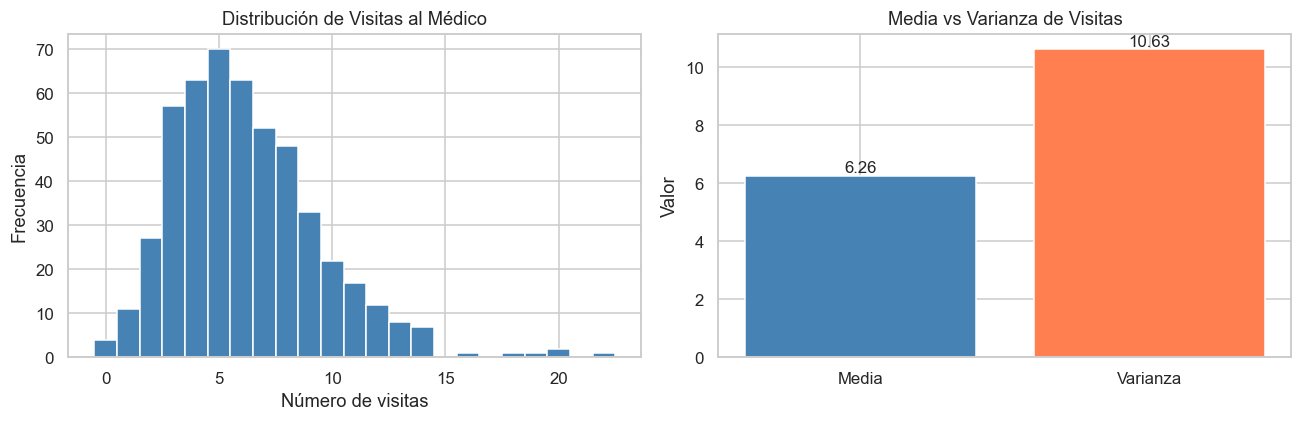


Media = 6.258,  Varianza = 10.629
Varianza / Media = 1.698  (ideal ≈ 1 para Poisson)


In [3]:
# Vista rápida de la distribución de conteos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de conteos
axes[0].hist(df['visits'], bins=range(0, df['visits'].max() + 2),
             edgecolor='white', color='steelblue', align='left')
axes[0].set(title='Distribución de Visitas al Médico', xlabel='Número de visitas',
            ylabel='Frecuencia')

# Verificación media vs varianza
mean_v = df['visits'].mean()
var_v = df['visits'].var()
axes[1].bar(['Media', 'Varianza'], [mean_v, var_v], color=['steelblue', 'coral'])
axes[1].set(title='Media vs Varianza de Visitas',
            ylabel='Valor')
for i, val in enumerate([mean_v, var_v]):
    axes[1].text(i, val + 0.1, f'{val:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()
print(f'\nMedia = {mean_v:.3f},  Varianza = {var_v:.3f}')
print(f'Varianza / Media = {var_v / mean_v:.3f}  (ideal ≈ 1 para Poisson)')

---

## 4. Ajuste de la Regresión de Poisson con `statsmodels`

Usamos `statsmodels.api.GLM` con `family=sm.families.Poisson()`. El enlace predeterminado para la familia de Poisson es el **enlace logarítmico**.

In [4]:
# Ajuste del MLG de Poisson
poisson_model = smf.glm(
    formula='visits ~ age + income_high',
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 visits   No. Observations:                  500
Model:                            GLM   Df Residuals:                      497
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1102.9
Date:                Fri, 20 Mar 2026   Deviance:                       430.76
Time:                        17:24:58   Pearson chi2:                     413.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.5497
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.7623      0.077      9.900      

---

## 5. Interpretación de Coeficientes como Razones de Tasas

Los coeficientes de la regresión de Poisson están en la **escala logarítmica**. Para interpretarlos en la escala original de conteos, se exponencian:

$$\text{Razón de Tasas (RTI)} = e^{\hat{\beta}_j}$$

**Reglas de interpretación:**

- $e^{\hat{\beta}_j} > 1$: un incremento unitario en $x_j$ **multiplica** el conteo esperado por $e^{\hat{\beta}_j}$ (la tasa aumenta).
- $e^{\hat{\beta}_j} < 1$: un incremento unitario en $x_j$ **reduce** el conteo esperado (la tasa disminuye).
- $e^{\hat{\beta}_j} = 1$: sin efecto.

El **cambio porcentual** en el conteo esperado por unidad de incremento en $x_j$ es $(e^{\hat{\beta}_j} - 1) \times 100\%$.

In [5]:
# Extraer coeficientes y calcular Razones de Tasas con IC del 95%
coef = poisson_model.params
ci = poisson_model.conf_int()

irr_table = pd.DataFrame({
    'Coeficiente (escala log)': coef,
    'Razón de Tasas (RTI)': np.exp(coef),
    'IC inferior RTI (95%)': np.exp(ci[0]),
    'IC superior RTI (95%)': np.exp(ci[1]),
    'valor-p': poisson_model.pvalues
})

print(irr_table.round(4))
print()
print('Valores verdaderos usados en la simulación:')
print('  Intercepto    β₀ = 0.800  → exp(β₀) = {:.3f}'.format(np.exp(0.800)))
print('  age           β₁ = 0.025  → RTI = {:.3f}  (cada año adicional → +{:.1f}% visitas)'.format(
      np.exp(0.025), (np.exp(0.025) - 1) * 100))
print('  income_high   β₂ = -0.400 → RTI = {:.3f}  (ingreso alto → {:.1f}% menos visitas)'.format(
      np.exp(-0.400), (np.exp(-0.400) - 1) * 100))

             Coeficiente (escala log)  Razón de Tasas (RTI)  \
Intercept                      0.7623                2.1431   
age                            0.0258                1.0262   
income_high                   -0.3991                0.6709   

             IC inferior RTI (95%)  IC superior RTI (95%)  valor-p  
Intercept                   1.8429                 2.4922      0.0  
age                         1.0231                 1.0292      0.0  
income_high                 0.6217                 0.7240      0.0  

Valores verdaderos usados en la simulación:
  Intercepto    β₀ = 0.800  → exp(β₀) = 2.226
  age           β₁ = 0.025  → RTI = 1.025  (cada año adicional → +2.5% visitas)
  income_high   β₂ = -0.400 → RTI = 0.670  (ingreso alto → -33.0% menos visitas)


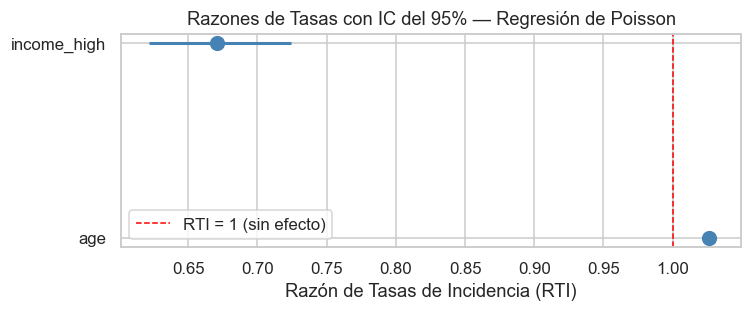

In [6]:
# Visualizar Razones de Tasas con intervalos de confianza (estilo gráfico de bosque)
irr_plot = irr_table.drop('Intercept').copy()

fig, ax = plt.subplots(figsize=(7, 3))
y_pos = range(len(irr_plot))

ax.scatter(irr_plot['Razón de Tasas (RTI)'], y_pos, color='steelblue', zorder=3, s=80)
for i, (idx, row) in enumerate(irr_plot.iterrows()):
    ax.hlines(i, row['IC inferior RTI (95%)'], row['IC superior RTI (95%)'],
              color='steelblue', linewidth=2)

ax.axvline(1, color='red', linestyle='--', linewidth=1, label='RTI = 1 (sin efecto)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(irr_plot.index)
ax.set(xlabel='Razón de Tasas de Incidencia (RTI)', title='Razones de Tasas con IC del 95% — Regresión de Poisson')
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. Variables Offset — Modelado de Tasas

En ocasiones, los conteos se registran durante **diferentes períodos de exposición** (tiempo, tamaño de población, área, etc.). Por ejemplo:

- Accidentes por hospital, pero los hospitales varían en número de camas.
- Conteos de crímenes por ciudad, pero las ciudades difieren en población.
- Reclamaciones de seguro por asegurado, pero los contratos tienen diferentes duraciones.

Para modelar la **tasa por unidad de exposición**, incluimos un **offset** — el logaritmo de la exposición — como predictor con coeficiente fijo igual a 1:

$$\log(\mu_i) = \log(t_i) + \beta_0 + \beta_1 x_{i1} + \ldots$$

lo que equivale a modelar la **tasa** $\lambda_i = \mu_i / t_i$:

$$\log\!\left(\frac{\mu_i}{t_i}\right) = \beta_0 + \beta_1 x_{i1} + \ldots$$

En `statsmodels` el offset se pasa como `exposure` (que la librería transforma logarítmicamente de forma automática) o como `offset` (transformado logarítmicamente de forma manual).

In [7]:
# ── Ejemplo con offset: reclamaciones de seguro por año de póliza ─────────────
np.random.seed(7)
n_ins = 400

# Exposición: duración de la póliza en años (varía de 0.5 a 5)
exposure = np.random.uniform(0.5, 5.0, size=n_ins)

# Predictor: grupo de edad del conductor (0 = joven, 1 = mayor)
senior = np.random.binomial(1, 0.35, size=n_ins)

# Modelo de tasa verdadero:  log(tasa) = -1.5 + 0.6*senior
log_rate = -1.5 + 0.6 * senior
mu_ins = np.exp(log_rate) * exposure   # reclamaciones esperadas = tasa * exposición

claims = np.random.poisson(mu_ins)

df_ins = pd.DataFrame({'claims': claims, 'exposure': exposure, 'senior': senior})

print('Conjunto de datos de seguros (primeras 8 filas):')
print(df_ins.head(8).to_string(index=False))
print(f'\nReclamaciones promedio: {claims.mean():.2f},  Exposición promedio: {exposure.mean():.2f} años')

Conjunto de datos de seguros (primeras 8 filas):
 claims  exposure  senior
      0  0.843387       1
      0  4.009635       0
      0  2.472842       0
      2  3.755593       0
      3  4.900953       1
      0  2.923231       0
      2  2.755042       1
      0  0.824230       1

Reclamaciones promedio: 0.74,  Exposición promedio: 2.74 años


In [8]:
# Ajuste de Poisson con offset de exposición
poisson_offset = smf.glm(
    formula='claims ~ senior',
    data=df_ins,
    family=sm.families.Poisson(),
    exposure=df_ins['exposure']   # statsmodels aplica el logaritmo internamente
).fit()

print(poisson_offset.summary())

print('\nRazones de Tasas:')
print(pd.DataFrame({
    'RTI': np.exp(poisson_offset.params),
    'IC inferior': np.exp(poisson_offset.conf_int()[0]),
    'IC superior': np.exp(poisson_offset.conf_int()[1]),
}).round(4))
print('\nRTI verdadera para senior: {:.3f}'.format(np.exp(0.6)))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 claims   No. Observations:                  400
Model:                            GLM   Df Residuals:                      398
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -420.71
Date:                Fri, 20 Mar 2026   Deviance:                       400.52
Time:                        17:24:58   Pearson chi2:                     387.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.05768
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.5498      0.081    -19.170      0.0

---

## 7. Sobredispersión: Diagnóstico

La **sobredispersión** ocurre cuando la varianza observada del resultado de conteo es mayor a lo que predice el modelo de Poisson (es decir, mayor que la media). Es una de las violaciones más comunes en los modelos de datos de conteo.

### Causas
- Heterogeneidad no observada (variables omitidas).
- Exceso de ceros (inflación de ceros).
- Agrupamiento o correlación entre observaciones.
- Efectos de contagio (un evento hace que eventos futuros sean más probables).

### Consecuencias de Ignorar la Sobredispersión
- Los errores estándar son **subestimados**, lo que lleva a valores-p espuriamente significativos.
- Las pruebas de hipótesis y los intervalos de confianza son **inválidos**.

### El Estadístico de Dispersión

Una verificación simple utiliza el **estadístico chi-cuadrado de Pearson** dividido por los grados de libertad:

$$\hat{\phi} = \frac{\chi^2_P}{n - p} = \frac{\sum_{i=1}^n (y_i - \hat{\mu}_i)^2 / \hat{\mu}_i}{n - p}$$

- $\hat{\phi} \approx 1$: equidispersión — Poisson es apropiado.
- $\hat{\phi} > 1$: sobredispersión — considerar Binomial Negativa o cuasi-Poisson.
- $\hat{\phi} < 1$: subdispersión (poco frecuente).

In [9]:
# ── Simular datos sobredispersos (proceso generador Binomial Negativa) ─────────
np.random.seed(99)
n_od = 600

x1 = np.random.normal(0, 1, n_od)
x2 = np.random.binomial(1, 0.5, n_od)

# Log-media verdadera
log_mu_od = 1.2 + 0.5 * x1 - 0.3 * x2
mu_od = np.exp(log_mu_od)

# Generar conteos sobredispersos (Binomial Negativa con dispersión α=0.8)
alpha_true = 0.8
r = 1.0 / alpha_true          # parámetro de forma
p_nb = r / (r + mu_od)        # probabilidad de éxito
y_od = np.random.negative_binomial(r, p_nb)

df_od = pd.DataFrame({'y': y_od, 'x1': x1, 'x2': x2})

print(f'Media:    {y_od.mean():.3f}')
print(f'Varianza: {y_od.var():.3f}')
print(f'Varianza / Media (bruta): {y_od.var() / y_od.mean():.3f}  (> 1 → sobredispersada)')

Media:    3.483
Varianza: 17.536
Varianza / Media (bruta): 5.034  (> 1 → sobredispersada)


In [10]:
# Ajuste de Poisson a los datos sobredispersos
poisson_od = smf.glm('y ~ x1 + x2', data=df_od,
                     family=sm.families.Poisson()).fit()

# Calcular estadístico de dispersión de Pearson
mu_hat = poisson_od.mu
pearson_chi2 = np.sum((y_od - mu_hat)**2 / mu_hat)
df_resid = poisson_od.df_resid
phi_hat = pearson_chi2 / df_resid

print(f'chi² de Pearson / gl  = {pearson_chi2:.2f} / {df_resid} = {phi_hat:.3f}')
print()
if phi_hat > 1.5:
    print('Estadístico de dispersión >> 1 → Evidencia fuerte de sobredispersión.')
    print('El modelo de Poisson subestima los errores estándar.')
elif phi_hat > 1.1:
    print('Sobredispersión leve detectada. Considerar Binomial Negativa o cuasi-Poisson.')
else:
    print('Sin evidencia fuerte de sobredispersión. El modelo de Poisson puede ser adecuado.')

# También se muestra en el resumen del modelo como 'Pearson chi2'
print()
print('Nota: statsmodels también reporta el chi² de Pearson en la tabla de resumen.')

chi² de Pearson / gl  = 1943.41 / 597 = 3.255

Estadístico de dispersión >> 1 → Evidencia fuerte de sobredispersión.
El modelo de Poisson subestima los errores estándar.

Nota: statsmodels también reporta el chi² de Pearson en la tabla de resumen.


---

## 8. Regresión Binomial Negativa

El modelo **Binomial Negativa (BN2)** extiende la regresión de Poisson añadiendo un **parámetro de dispersión** $\alpha \geq 0$:

$$\text{Var}(Y_i) = \mu_i + \alpha \mu_i^2$$

Cuando $\alpha = 0$ el modelo se reduce a Poisson. A medida que $\alpha$ aumenta, la distribución se vuelve más dispersa, acomodando la sobredispersión.

La función de enlace y el predictor lineal son **idénticos** a los de la regresión de Poisson, por lo que la interpretación de los coeficientes como razones de tasas se mantiene.

En `statsmodels` usamos `sm.families.NegativeBinomial()` para la interfaz GLM, o `smf.negativebinomial()` que estima $\alpha$ conjuntamente con $\boldsymbol{\beta}$ vía EMV.

In [11]:
# Ajuste de la regresión Binomial Negativa
nb_model = smf.negativebinomial('y ~ x1 + x2', data=df_od).fit(disp=False)
print(nb_model.summary())

                     NegativeBinomial Regression Results                      
Dep. Variable:                      y   No. Observations:                  600
Model:               NegativeBinomial   Df Residuals:                      597
Method:                           MLE   Df Model:                            2
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                 0.05052
Time:                        17:24:58   Log-Likelihood:                -1354.7
converged:                       True   LL-Null:                       -1426.8
Covariance Type:            nonrobust   LLR p-value:                 4.982e-32
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2388      0.059     21.031      0.000       1.123       1.354
x1             0.5119      0.043     11.973      0.000       0.428       0.596
x2            -0.2477      0.080     -3.090      0.0

In [12]:
# Comparar coeficientes y errores estándar de Poisson vs Binomial Negativa
comparison = pd.DataFrame({
    'Coef. Poisson': poisson_od.params,
    'EE Poisson': poisson_od.bse,
    'Coef. BN': nb_model.params.drop('alpha', errors='ignore').reindex(poisson_od.params.index),
    'EE BN': nb_model.bse.drop('alpha', errors='ignore').reindex(poisson_od.params.index),
})

print('Comparación de coeficientes — Poisson vs Binomial Negativa:')
print(comparison.round(4))
print()
print(f'Alpha estimado (dispersión): {nb_model.params["alpha"]:.4f}')
print(f'Alpha verdadero usado en la simulación: {alpha_true}')
print()
print('Nota: Los EE de BN son mayores (los EE de Poisson estaban subestimados).')

Comparación de coeficientes — Poisson vs Binomial Negativa:
           Coef. Poisson  EE Poisson  Coef. BN   EE BN
Intercept         1.2609      0.0324    1.2388  0.0589
x1                0.4942      0.0228    0.5119  0.0428
x2               -0.2811      0.0438   -0.2477  0.0802

Alpha estimado (dispersión): 0.6220
Alpha verdadero usado en la simulación: 0.8

Nota: Los EE de BN son mayores (los EE de Poisson estaban subestimados).


In [13]:
# Comparación por AIC
print('Comparación de modelos por AIC (menor es mejor):')
print(f'  AIC Poisson:           {poisson_od.aic:.2f}')
print(f'  AIC Binomial Negativa: {nb_model.aic:.2f}')
delta_aic = poisson_od.aic - nb_model.aic
print(f'  ΔAIC (Poisson - BN):   {delta_aic:.2f}')
if delta_aic > 10:
    print('\n  Preferencia fuerte por el modelo Binomial Negativa.')

Comparación de modelos por AIC (menor es mejor):
  AIC Poisson:           3326.29
  AIC Binomial Negativa: 2717.50
  ΔAIC (Poisson - BN):   608.79

  Preferencia fuerte por el modelo Binomial Negativa.


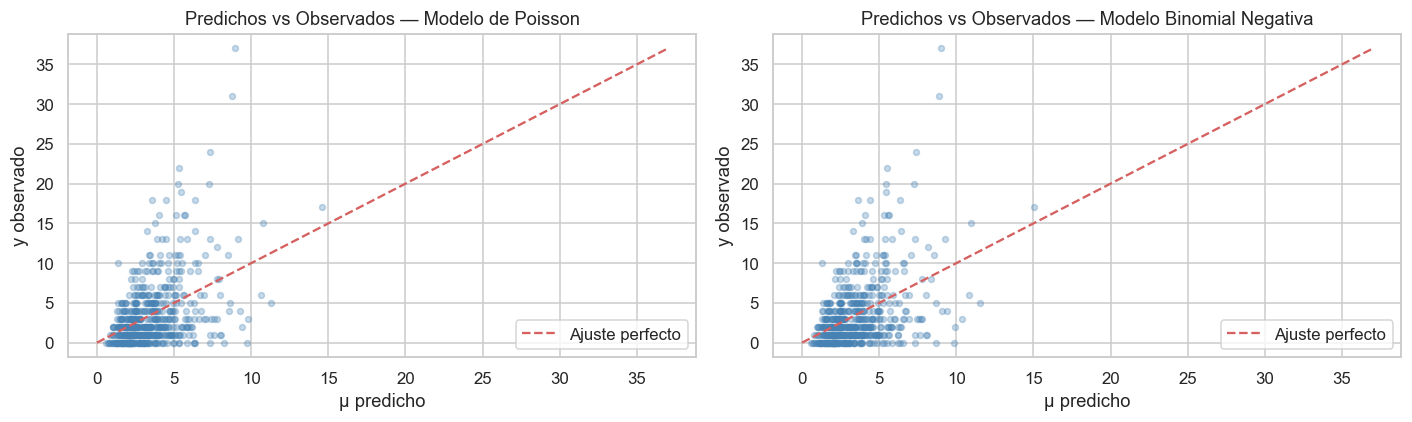

In [14]:
# Visual: comparar distribuciones predichas de ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model, title in zip(
    axes,
    [poisson_od, nb_model],
    ['Modelo de Poisson', 'Modelo Binomial Negativa']
):
    mu_pred = model.predict()
    observed_counts = df_od['y'].values
    ax.scatter(mu_pred, observed_counts, alpha=0.3, s=15, color='steelblue')
    max_val = max(mu_pred.max(), observed_counts.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='Ajuste perfecto')
    ax.set(xlabel='μ predicho', ylabel='y observado',
           title=f'Predichos vs Observados — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

---

## 9. Resumen

| Concepto | Conclusión clave |
|---|---|
| **Cuándo usar regresión de Poisson** | Conteos enteros no negativos; eventos por unidad de exposición |
| **Función de enlace** | El enlace logarítmico garantiza que los conteos predichos sean siempre positivos |
| **Interpretación de coeficientes** | Exponenciar para obtener Razones de Tasas de Incidencia (RTI) |
| **Offset** | Usar `exposure=` cuando los conteos provienen de distintas ventanas de exposición |
| **Sobredispersión** | Verificar $\phi = \chi^2_P / gl$ de Pearson; $\phi \gg 1$ señala un problema |
| **Binomial Negativa** | Añade parámetro de dispersión $\alpha$; se reduce a Poisson cuando $\alpha=0$ |
| **Selección de modelos** | Comparar AIC; la BN casi siempre gana cuando los datos son sobredispersos |

---

*Siguiente: `13-2-Ejemplo_Poisson.ipynb` — ejemplo aplicado completo sobre un conjunto de datos de conteo realista.*